# Plot

In [2]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from scipy.optimize import minimize, brentq
from cms_top_20_001_Limits import read_CMSdata, getSMLO, getKfactor

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

colors = sns.color_palette('Paired')

### Load Recast Data

In [100]:
recastDataAll = pd.read_pickle('/home/vinicius/EFT_ToyModel/Recast_CMS/pp2ttbar_cms_top_20_001.pcl')
recastDataEFTAll = pd.read_pickle('/home/vinicius/EFT_ToyModel/Recast_CMS/pp2ttbar_eft_cms_top_20_001.pcl')
recastDataZAll = pd.read_pickle('/home/vinicius/EFT_ToyModel/Recast_CMS/pp_Zp_test.pcl')
recastDataScalarAll = pd.read_pickle('/home/vinicius/EFT_ToyModel/Recast_CMS/pp_Scalar_test.pcl')
print(recastDataScalarAll)

           model   mPsiT    mSDM     mT   yDM              process  xsec (pb)  \
0  1-loop Scalar   400.0   300.0  172.5   5.0  $p p \to t \bar{t}$  -2.228300   
1  1-loop Scalar   500.0   375.0  172.5   1.0  $p p \to t \bar{t}$  -0.063440   
2  1-loop Scalar   500.0   400.0  172.5   5.0  $p p \to t \bar{t}$  -1.489300   
3  1-loop Scalar   500.0   475.0  172.5   1.0  $p p \to t \bar{t}$  -0.051500   
4  1-loop Scalar   600.0   475.0  172.5   1.0  $p p \to t \bar{t}$  -0.044841   
5  1-loop Scalar   600.0   500.0  172.5   5.0  $p p \to t \bar{t}$  -1.075100   
6  1-loop Scalar   700.0   600.0  172.5   5.0  $p p \to t \bar{t}$  -0.794000   
7  1-loop Scalar  1000.0   900.0  172.5  10.0  $p p \to t \bar{t}$  -1.562600   
8  1-loop Scalar  1500.0  1425.0  172.5   1.0  $p p \to t \bar{t}$  -0.006934   

   MC Events                                               file  bin_250_400  \
0     348315  /home/vinicius/EFT_ToyModel/processFolders/Dis...    -0.789379   
1    6147853  /home/vinicius/

### Get CMS data

In [101]:
cms_bins = np.array([250.,400.,480.,560.,640.,720.,800.,900.,1000.,
                1150.,1300.,1500.,1700.,2000.,2300.,3500.])
bin_widths  = cms_bins[1:]-cms_bins[:-1] 

# ### Load CMS data
xsecsObs,smNLO,covMatrix,sm_err = read_CMSdata(dataDir='/home/vinicius/EFT_ToyModel/Recast_CMS/data')
smNLO = smNLO/bin_widths
sm_err = sm_err/bin_widths
covTotal = covMatrix + np.diag( (sm_err)**2) 
bgError = np.sqrt(covTotal.diagonal())
#bgError = np.sqrt(covMatrix.diagonal())       

### Get SM prediction and k-factor

In [102]:
# ### Load SM prediction (LO)
smLO = getSMLO('/home/vinicius/EFT_ToyModel/Recast_CMS/sm/sm_tt_lo_cms_top_20_001.pcl')
# ### Load k-factors
kfac = 1.0#getKfactor(smNLO,smLO)
smNLO = smNLO
print(smNLO)
print(xsecsObs)

[3.27717183e-01 8.81521972e-01 5.44329014e-01 3.18260563e-01
 1.82089014e-01 1.09291268e-01 6.47404038e-02 3.65881502e-02
 1.91298404e-02 9.06418779e-03 4.25560563e-03 1.77232207e-03
 6.79761784e-04 2.36470423e-04 3.74685070e-05]
[3.442e-01 8.717e-01 5.428e-01 3.153e-01 1.809e-01 1.096e-01 6.251e-02
 3.697e-02 1.784e-02 9.005e-03 3.815e-03 1.769e-03 6.941e-04 1.905e-04
 3.147e-05]


## Heavy Point 1

### Select parameters

In [104]:
mPsiT = 1000.0
mSDM = 900.0
yDM = 1.0
mZp = 2000.0

recastData = recastDataAll[(recastDataAll['mPsiT'] == mPsiT) & (recastDataAll['mSDM'] == mSDM) & (recastDataAll['yDM'] == yDM)]
recastDataEFT = recastDataEFTAll[(recastDataEFTAll['mPsiT'] == mPsiT) & (recastDataEFTAll['mSDM'] == mSDM) & (recastDataEFTAll['yDM'] == yDM)]
recastDataZ = recastDataZAll[(recastDataZAll['mZp'] == mZp)]
recastDataScalar = recastDataScalarAll[(recastDataScalarAll['mPsiT'] == mPsiT) & (recastDataScalarAll['mSDM'] == mSDM) & (recastDataScalarAll['yDM'] == 10.0*yDM)]
print(mPsiT,mSDM,yDM, mZp)
print(len(recastData),len(recastDataEFT), len(recastDataZ), len(recastDataScalar))
#print(recastData.iloc[0]['xsec (pb)'],recastDataScalar.iloc[0]['xsec (pb)'])

1000.0 900.0 1.0 2000.0
1 1 1 1


### Get signal

In [105]:
binCols = [c for c in recastData.columns 
               if 'bin_' in c.lower() and not 'error' in c.lower()]
bins_left = np.array([eval(c.split('_')[1]) for c in binCols])
bins_right = np.array([eval(c.split('_')[2]) for c in binCols])     
bin_centers = (bins_left+bins_right)/2.0
bin_widths = bins_right-bins_left
cms_bins = np.append(bins_left,bins_right[-1])

signal = list(zip(bins_left,recastData.iloc[0][binCols].values))
signal = np.array(sorted(signal))[:,1]

signalEFT = list(zip(bins_left,recastDataEFT.iloc[0][binCols].values))
signalEFT = np.array(sorted(signalEFT))[:,1]

signalZ = list(zip(bins_left,recastDataZ.iloc[0][binCols].values))
signalZ = np.array(sorted(signalZ))[:,1]

signalS = list(zip(bins_left,recastDataScalar.iloc[0][binCols].values))
signalS = np.array(sorted(signalS))[:,1]


### Apply k-factors and rescale by bins

In [107]:
signalNLO = signal*kfac/bin_widths
signalEFTNLO = signalEFT*kfac/bin_widths
signalSNLO = signalS*kfac/(bin_widths * 10.0**2)
signalZp = signalZ*kfac/bin_widths

### Plot distribution and data

0.0004040680541797546 -1.5626870415724443


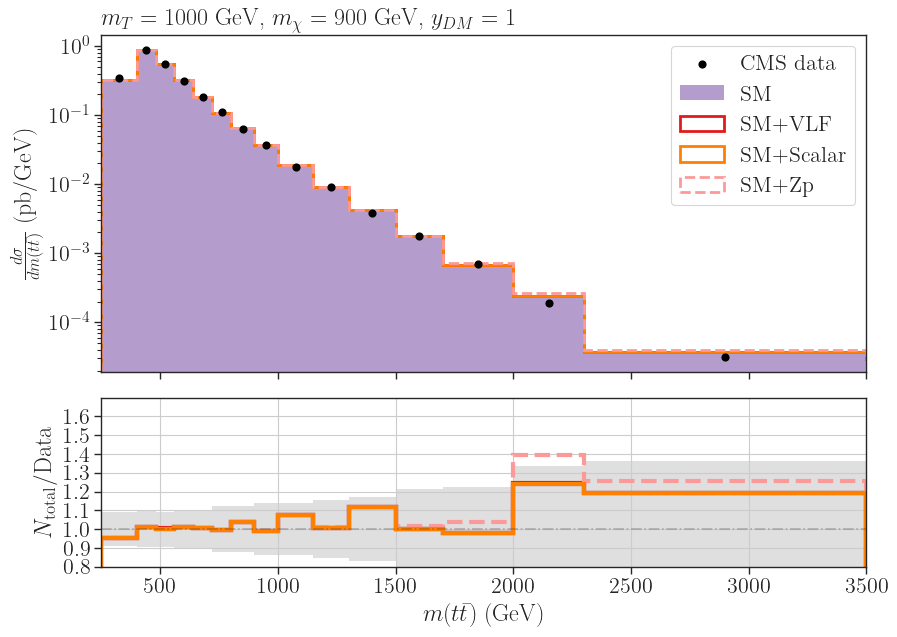

In [109]:
# yDM = 1.0/recastData.iloc[0]['yDM']
yDM_S = 1.0#(1.0/recastDataScalar.iloc[0]['yDM']) * yDM * np.sqrt(recastData.iloc[0]['xsec (pb)']/recastDataScalar.iloc[0]['xsec (pb)'])
print(sum(signalNLO*yDM**2),sum(signalS*yDM_S**2 ))
mu = 1.0

_, axarr = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2, 1]},figsize=(9,7))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

axarr[0].scatter(bin_centers,xsecsObs,label='CMS data',linewidth=2,s=15,
c='black',zorder=10)
axarr[0].hist(bin_centers,weights=smNLO,label=r'SM',histtype='step',linewidth=0,bins=cms_bins,color=colors[9],fill=True,alpha=0.5)
axarr[0].hist(bin_centers,weights=smNLO+signalNLO*yDM**2,label=r'SM+VLF',histtype='step',linewidth=2,bins=cms_bins,color=colors[5])
axarr[0].hist(bin_centers,weights=smNLO+signalSNLO*yDM_S**2,label=r'SM+Scalar',histtype='step',linewidth=2,bins=cms_bins,color=colors[7])
#axarr[0].hist(bin_centers,weights=smNLO+signalEFTNLO*yDM**2,label=r'SM+EFT',histtype='step',linewidth=2,bins=cms_bins,linestyle='dashed',color=colors[4])
axarr[0].hist(bin_centers,weights=smNLO+signalZp*mu**2,label=r'SM+Zp',histtype='step',linewidth=2,bins=cms_bins,linestyle='dashed',color=colors[4])
axarr[0].set_yscale('log')
# axarr[0].set_ylim(1e-6,2e-2)
axarr[0].legend()
axarr[0].set_xlim(250.,3500.)
# axarr[0].grid()

axarr[1].hist(bin_centers,weights=np.divide(smNLO,xsecsObs),histtype='step',linewidth=3,bins=cms_bins,color=colors[9])
axarr[1].hist(bin_centers,weights=np.divide(smNLO+signalNLO*yDM**2,xsecsObs),histtype='step',linewidth=3,bins=cms_bins,color=colors[5])
#axarr[1].hist(bin_centers,weights=np.divide(smNLO+signalEFTNLO*yDM**2,xsecsObs),histtype='step',linewidth=3,bins=cms_bins,color=colors[4],linestyle='dashed')
axarr[1].hist(bin_centers,weights=np.divide(smNLO+signalZp*mu**2,xsecsObs),histtype='step',linewidth=3,bins=cms_bins,color=colors[4],linestyle='dashed')
axarr[1].hist(bin_centers,weights=np.divide(smNLO+signalSNLO*yDM_S**2,xsecsObs),histtype='step',linewidth=3,bins=cms_bins,color=colors[7])
# axarr[1].bar(x=bins_left, height=np.divide(2*bgError,xsecsObs), bottom=np.divide(smNLO-bgError,xsecsObs), width=bin_widths, align='edge', linewidth=0, color=colors[0], alpha=0.25, zorder=-1, label='uncertainty band')
axarr[1].bar(x=bins_left, height=np.divide(2*bgError,xsecsObs), bottom=np.divide(xsecsObs-bgError,xsecsObs), width=bin_widths, align='edge', linewidth=0, color='gray', alpha=0.25, zorder=-1, label='uncertainty band')

axarr[1].axhline(y=1, ls = '-.', color = 'k', alpha = 0.25)
axarr[1].set_ylim(0.8,1.7)
axarr[1].set_yticks(np.arange(0.8,1.7,0.1))
axarr[1].grid()

axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
axarr[0].set_ylabel(r'$\frac{d \sigma}{d m(t\bar{t})}$ (pb/GeV)')
axarr[1].set_ylabel(r'$N_{\rm total}/{\rm Data}$')


axarr[0].set_title(r'$m_T = %1.0f$ GeV, $m_{\chi} = %1.0f$ GeV, $y_{DM} = %1.0f$' %(mPsiT,mSDM,yDM),loc='left')
#plt.savefig('CMS_mtt_mPsiT%i_mSDM%i_yDM_%i.png' %(int(mPsiT),int(mSDM),int(yDM)))
plt.show()

-0.006895
